In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
data = pd.read_csv(r"C:\Users\Lenovo\OneDrive\Desktop\ft\project\1768456122330-ML Project - Linear Regression Insurance Prediction 16955515670.txt")

In [3]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [5]:
data['children'] = data['children'].fillna(0)

In [8]:
data['bmi'] = data['bmi'].fillna(data['bmi'].mean())

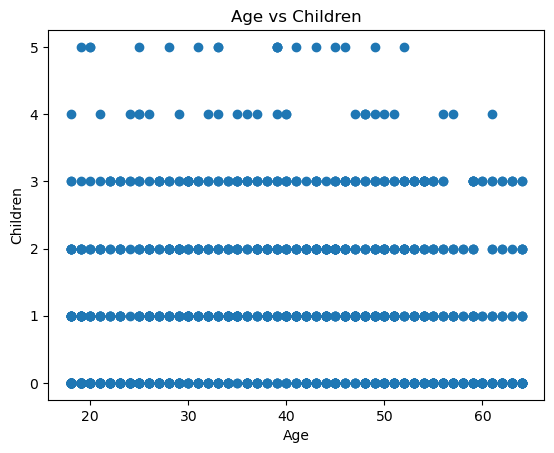

In [10]:
plt.scatter(data['age'],data['children'])
plt.xlabel("Age")
plt.ylabel("Children")
plt.title("Age vs Children")
plt.show()

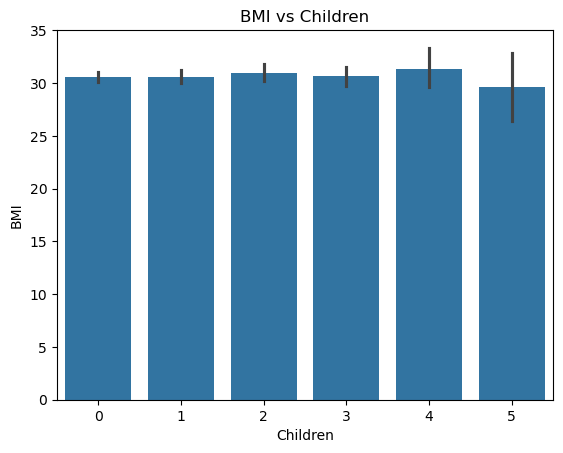

In [11]:
plt.Figure(figsize=(10,5))
sns.barplot(x=data['children'], y=data['bmi'])
plt.xlabel("Children")
plt.ylabel("BMI")
plt.title("BMI vs Children")

plt.show()

In [12]:
from sklearn.preprocessing import LabelEncoder

In [13]:
encoder = LabelEncoder()

In [14]:
data.head(2)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.9240
1,18,male,33.77,1,no,southeast,1725.5523


In [15]:
data["sex"] = encoder.fit_transform(data["sex"])
data["smoker"] = encoder.fit_transform(data["smoker"])
data['region'] = encoder.fit_transform(data['region'])

In [16]:
from sklearn.preprocessing import StandardScaler

In [17]:
scalere = StandardScaler() 

In [18]:
data.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [19]:
features = ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

In [20]:
data[features] = scalere.fit_transform(data[features])

In [21]:
data.head(1)

,age,sex,bmi,children,smoker,region,charges
0,-1.438764,-1.010519,-0.45332,-0.908614,1.970587,1.343905,0.298584


In [22]:
x= data.drop('charges',axis=1)
y= data['charges']

In [23]:
from sklearn.model_selection import train_test_split

In [28]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [25]:
from sklearn.linear_model import LinearRegression

In [27]:
model = LinearRegression()

In [29]:
model.fit(x_train,y_train)

LinearRegression()

In [31]:
model.score(x_train,y_train)

0.7417049283233981

In [30]:
model.score(x_test,y_test)

0.7833463107364536

In [32]:
model.coef_

array([ 2.98235092e-01, -7.76112153e-04,  1.69088059e-01,  4.23157876e-02,
        7.88313320e-01, -2.47512482e-02])

In [33]:
model.intercept_

0.0037192171226022998

In [34]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,root_mean_squared_error,r2_score

In [37]:
y_pred = model.predict(X_test)

In [38]:
print("mean absolute error : ",mean_absolute_error(y_test,y_pred))
print("mean square error : ",mean_squared_error(y_test,y_pred))
print("root mean squared error : ",root_mean_squared_error(y_test,y_pred))
print("r2 score : ",r2_score(y_test,y_pred))

mean absolute error :  0.3458357023132989
mean square error :  0.22952487683968598
root mean squared error :  0.4790875461120712
r2 score :  0.7833463107364536
